We have performed various experiments with training of GANs. \
Our experiments are listed as below: 
| Experiment # | Question # | Model Type          | Dataset Description                     | Key Parameters (e.g., Batch Size, Learning Rate) | Results (e.g., FID Score, Epochs) | Notes/Observations                              |
|--------------|------------|---------------------|------------------------------------------|-------------------------------------------------|----------------------------------|------------------------------------------------|
| 1            | Q1,Q2       | DCGAN  with Discriminator trained once w.r.t. Generator              |Butterfly Images, 75 classes | Batch Size: 128, Learning Rate: 0.0002            | FID: 150.02, 5100 iterations      | Images become clearer after 5100 iterations       |

To avoid confusion, before every question there is a list of experiments performed in that question.

In [4]:
import os
import random
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

# Set random seed for reproducibility
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True)

Using device:  cuda


In [5]:
# Calculate mean and standard deviation from the given data
def mean_std(dataset):
    mean = 0.0
    std = 0.0
    num_samples = 0
    for (
        images,
        _,
    ) in dataset:  # _ is labels of images from 0 to 89 assigned to each number
        images = images.to(device)
        batch_samples = images.size(0)  # no of images in one batch
        images = images.view(
            batch_samples, images.size(1), -1
        )  # Reshape to (batch size, 3 (RGB), H*W)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        num_samples += batch_samples
    print("Number of Images: ", num_samples)
    return mean / num_samples, std / num_samples

##### Load data


In [6]:
path = os.path.join(os.getcwd(), "data", "butterfly")
image_width = 128
image_height = 128
batch_size = 128
num_workers = 8
# transform1 = transforms.Compose([transforms.Resize((image_height,image_width)),transforms.ToTensor()])
# train_data = datasets.ImageFolder(root = path, transform = transform1)
# train_loader = DataLoader(train_data,batch_size=batch_size)
# mean, std = mean_std(train_loader)
mean = torch.tensor([0.47998455, 0.46537864, 0.33653912]) # After Calculation, Mean is directly given to the code.
std = torch.tensor([0.22608626, 0.22103393, 0.21348171])
transform = transforms.Compose(
    [
        transforms.Resize((image_height, image_width)),
        transforms.CenterCrop((image_height, image_width)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)
norm_train_data = datasets.ImageFolder(root=path, transform=transform)

norm_train_loader = DataLoader(
    norm_train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
# We are not spliting train and test data like conventional machine learning for calculating accuracy.
print("Mean: ", mean.cpu().numpy(), "Std dev: ", std.cpu().numpy())

Mean:  [0.47998455 0.46537864 0.33653912] Std dev:  [0.22608626 0.22103393 0.21348171]


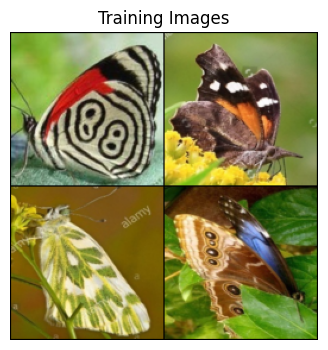

In [7]:
# Display some training images for reference
dataiter = iter(norm_train_loader)
batch = next(dataiter)
plt.figure(figsize=(4, 4))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(
            (batch[0] * std[:, None, None] + mean[:, None, None]).to(device)[:4],
            nrow=2,
            padding=1,
        ).cpu(),
        (1, 2, 0),
    )
)
plt.show()

In [8]:
CUDA_LAUNCH_BLOCKING=1
n_channels = 3  # RGB
z_latent = 100
fg = 128  # size of feature maps in generator
fd = 128  # size of feature maps in discriminator
n_epochs = 100 # number of epochs
beta1 = 0.5  # beta1 value for Adam optimizer Given in Paper
lr = 2e-4  # Learning rate for Adam optimizer Given in Paper


# function to initialize weights for any object
def weights_init(c):
    class_name = c.__class__.__name__
    if class_name.find("Conv") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Conv layer weights is taken 0.0
    elif class_name.find("BatchNorm") != -1:
        nn.init.normal_(c.weight.data, 0.0, 0.02)
        # mean of Batch Normalization layer weights is taken 0.0
        nn.init.constant_(c.bias.data, 0)

In [9]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            self.block(z_latent, fg * 8, 4, 1, 0),  # (batch size, 1024, 4, 4)
            self.block(fg * 8, fg * 4, 4, 2, 1), # (batch size, 512, 8, 8)
            self.block(fg * 4, fg * 2, 4, 2, 1), # (batch size, 256, 16, 16)
            self.block(fg * 2, fg, 4, 2, 1), # (batch size, 128, 32, 32)
            self.block(fg , fg//2, 4, 2, 1), # (batch size, 64, 64, 64)
            nn.ConvTranspose2d(fg//2, n_channels, 4, 2, 1, bias=False), # (batch size, 3, 128, 128)
            nn.Tanh(),
        )
    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernal_size, stride, padding, bias=False), # Transposed Convolution
            nn.BatchNorm2d(out_channels),  # Batch Normalization
            nn.ReLU(True), # ReLU activation function
        )
    def forward(self, z):
        return self.main(z)
    
gen = Generator().to(device)
gen.apply(weights_init)
# print(gen)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            self.block(n_channels, fd, 4, 2, 1), # (batch size, 128, 64, 64)
            self.block(fd, fd * 2, 4, 2, 1), # (batch size, 256, 32, 32)
            self.block(fd * 2, fd * 4, 4, 2, 1), # (batch size, 512, 16, 16)
            self.block(fd * 4, fd * 8, 4, 2, 1), # (batch size, 1024, 8, 8)
            self.block(fd * 8, fd * 16, 4, 2, 1), # (batch size, 2048, 4, 4)
            nn.Conv2d(fd * 16, 1, 4, 1, 0, bias=False), # (batch size, 1, 1, 1)
            nn.Sigmoid(), # Sigmoid activation function
        )
    def block(self, in_channels, out_channels, kernal_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernal_size, stride, padding, bias=False), # Convolution
            nn.BatchNorm2d(out_channels), # Batch Normalization
            nn.LeakyReLU(0.2, inplace=True), # Leaky ReLU activation function
        )

    def forward(self, z):
        return self.main(z)
dis = Discriminator().to(device)
dis.apply(weights_init)
# print(dis)
# Test for the architecture of the generator and discriminator
# This function is just for testing purpose for the input and output shapes of the generator and discriminator
def test():
    N, in_channels, H, W = 64, 3, 128, 128
    x = torch.randn((N, in_channels, H, W))  # 64,3,128,128
    disc = Discriminator()

    assert disc(x).shape == (N, 1, 1, 1), "Discriminator test failed"
    gen = Generator()
    z = torch.randn((N, z_latent, 1, 1))
    assert gen(z).shape == (N, in_channels, H, W), "Generator test failed"
    print("All architectural tests passed")
test()
criterion = nn.BCELoss()
optimizer_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_dis = torch.optim.Adam(dis.parameters(), lr=lr, betas=(beta1, 0.999))

All architectural tests passed


In [ ]:
img_list = []
G_losses = []
D_losses = []
iters = 0
fixed_sample = torch.randn(100, z_latent, 1, 1, device=device)  # Ensure 64 images
print("Training starts ...")
for epoch in range(n_epochs):
    for i, data in enumerate(norm_train_loader, 0):
        ############################
        ## Discriminator Training ##
        ############################
        dis.zero_grad()
        # Importing real images data. data[0] means images
        real_data = data[0].to(device)
        batch_size = real_data.size(0)
        # Giving real data to discriminator
        discriminator_output_real = dis(real_data).view(-1)
        # 0.9 is used for label smoothing
        error_dis_real = criterion(discriminator_output_real,  torch.full_like(discriminator_output_real, 0.9))
        error_dis_real.backward()
        # D(X) for real data will be mean of output of all data in batch of this iteration
        D_x = discriminator_output_real.mean().item()

        # Training with fake data, Sampling from normal distribution P_z(z)
        sample = torch.randn(batch_size, z_latent, 1, 1, device=device)
        # Input this sampled data to generator
        generator_output = gen(sample)
        # Giving fake data to discriminator
        discriminator_output_fake = dis(generator_output.detach()).view(-1)
        # 0.1 is used for label smoothing
        error_dis_fake = criterion(discriminator_output_fake,  torch.full_like(discriminator_output_fake, 0))
        error_dis_fake.backward()
        # D(G(z)) for fake data will be mean of output of all data in batch of this iteration
        D_G_z1 = discriminator_output_fake.mean().item()
        # Discriminator Total Loss
        error_dis = error_dis_real + error_dis_fake
        # nn.utils.clip_grad_value_(gen.parameters(), 0.1)
        optimizer_dis.step()
        
        ########################
        ## Generator Training ##
        ########################
        gen.zero_grad()
        # Giving fake data to discriminator
        discriminator_output_fake = dis(generator_output).view(-1)
        # Binary cross entropy for generator
        error_gen = criterion(discriminator_output_fake,  torch.full_like(discriminator_output_fake, 0.9))
        # Backpropogation for generator
        error_gen.backward()
        nn.utils.clip_grad_value_(gen.parameters(), 0.1)
        optimizer_gen.step()
        # D(G(z)) for fake data will be mean of output of all data in batch of this iteration
        D_G_z2 = discriminator_output_fake.mean().item()

        if i % 100 == 0:
            print(
                "[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f"
                % (
                    epoch,
                    n_epochs,
                    i,
                    len(norm_train_loader),
                    error_dis.item(),
                    error_gen.item(),
                    D_x,
                    D_G_z1,
                    D_G_z2,
                )
            )

        # Generator and Discriminator Losses
        G_losses.append(error_gen.item())
        D_losses.append(error_dis.item())
        iters += 1
print("Training ends ...")
torch.save(dis, "discriminator.pth")
torch.save(gen, "generator.pth")

Training starts ...
[0/100][0/51]	Loss_D: 1.3850	Loss_G: 0.9775	D(x): 0.5051	D(G(z)): 0.5040 / 0.3548
[1/100][0/51]	Loss_D: 0.6883	Loss_G: 2.6243	D(x): 0.9102	D(G(z)): 0.0413 / 0.0546
[2/100][0/51]	Loss_D: 0.6872	Loss_G: 2.9491	D(x): 0.8909	D(G(z)): 0.1906 / 0.0380
[3/100][0/51]	Loss_D: 0.7041	Loss_G: 2.7255	D(x): 0.8678	D(G(z)): 0.1801 / 0.0499
[4/100][0/51]	Loss_D: 0.8728	Loss_G: 3.5565	D(x): 0.8583	D(G(z)): 0.3620 / 0.0195
[5/100][0/51]	Loss_D: 0.6975	Loss_G: 2.5517	D(x): 0.9075	D(G(z)): 0.1507 / 0.0620
[6/100][0/51]	Loss_D: 0.7748	Loss_G: 2.0891	D(x): 0.8009	D(G(z)): 0.2511 / 0.1008
[7/100][0/51]	Loss_D: 0.7422	Loss_G: 2.2084	D(x): 0.7643	D(G(z)): 0.0760 / 0.0910
[8/100][0/51]	Loss_D: 0.8592	Loss_G: 2.2008	D(x): 0.8265	D(G(z)): 0.3361 / 0.0923
[9/100][0/51]	Loss_D: 0.7909	Loss_G: 1.3818	D(x): 0.9081	D(G(z)): 0.2836 / 0.2332
[10/100][0/51]	Loss_D: 0.7804	Loss_G: 2.3529	D(x): 0.7372	D(G(z)): 0.0492 / 0.0815
[11/100][0/51]	Loss_D: 0.6843	Loss_G: 2.3153	D(x): 0.9277	D(G(z)): 0.1480 / 0

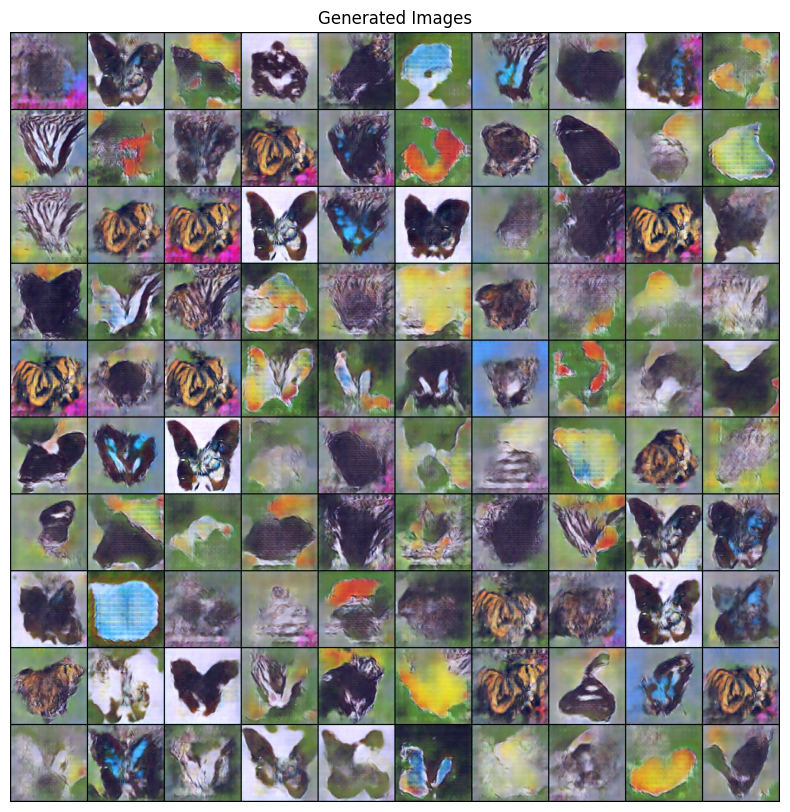

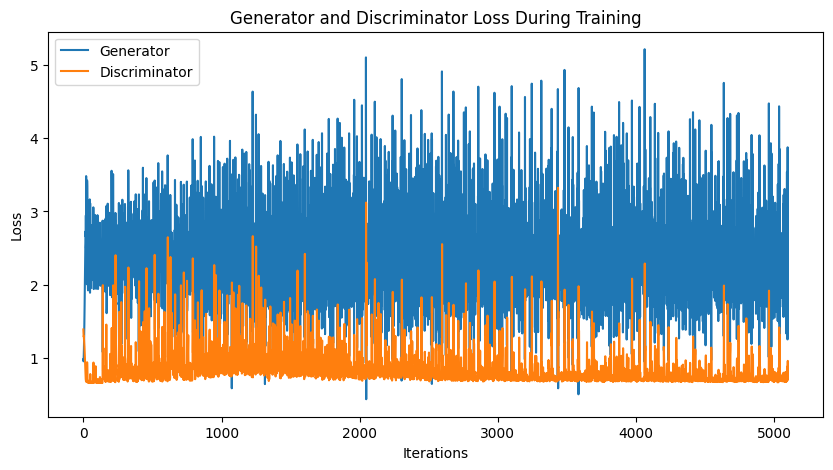

In [11]:
with torch.no_grad():
    fake = gen(fixed_sample).detach().cpu()
gen_img = vutils.make_grid(fake, nrow=10, padding=2, normalize=True)
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(gen_img, (1, 2, 0)))
plt.show()

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Code using which FID is calculated in all the questions.
import numpy as np
fake_images = []
latent_dim = 100
for i in range(1000):
    noise = torch.randn(1, latent_dim, 1, 1).to(device)
    img = gen(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
# sample 1000 images from the training set
for i in range(1000):
    img = norm_train_data[i][0].numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    real_images.append(img)


import torch
! pip install torcheval
from torcheval.metrics import FrechetInceptionDistance

# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

#### Q1,Q2 Learnings: 

Without Gradient Clipping, Generator_Loss quickly went to zero and Discriminator_Loss quickly went to 1 \
After Apply gradient clipping of 0.1 to generator parameters, I got stable results. (Unstable result not shown)

When Discriminator becomes overconfident, Label smoothing helps. \
Label smoothing: label 1 changes to 0.9 and label 0 remains 0